# Three-way comparison: MATLAB, BAYSPARpy, and `brews/baysparpy`

Runs Jess Tierney's two demo examples through every available implementation and compares the
answers.

| | What it is |
|---|---|
| **MATLAB** | `bayspar_tex.m` / `bayspar_tex_analog.m` run unmodified, their output saved to `docs/BAYSPARpy/audit/original_matlab.mat` by `audit/verify_original.m`. The reference. |
| **BAYSPARpy** | this port (`import baysparpy`) |
| **brews/baysparpy** | S. B. Malevich's port (`import bayspar`), `pip install baysparpy` — optional; the notebook says so and carries on if it is missing |

The two examples are the ones shipped with the MATLAB package:

1. `Demo_StandardPrediction.m` — a TEX₈₆ time series (`lopes_santos2010`) at a known site.
2. `Demo_AnalogPrediction.m` — the Wilson Lake PETM record, analogue mode.

**To regenerate the MATLAB reference** (from the repository root; both work):

```bash
matlab -batch "addpath('docs/BAYSPARpy/audit'); verify_original"
octave --no-gui --quiet --eval "pkg load statistics; addpath('docs/BAYSPARpy/audit'); verify_original"
```

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt

import baysparpy as ours

# brews/baysparpy is optional. Both packages coexist because this one imports as
# `baysparpy` and his as `bayspar` -- that is why the import name was chosen.
try:
    import bayspar as brews
    HAVE_BREWS = True
except ImportError:
    brews, HAVE_BREWS = None, False

ROOT = next(p for p in Path.cwd().resolve().parents if (p / "ModelOutput").is_dir()) \
    if not (Path.cwd() / "ModelOutput").is_dir() else Path.cwd()
REF = ROOT / "docs" / "BAYSPARpy" / "audit" / "original_matlab.mat"
HAVE_REF = REF.is_file()

N_DRAWS = 1000          # MATLAB's default, and what the saved reference used
SEED = 0

print(f"BAYSPARpy        {ours.__version__}")
print(f"brews/baysparpy  {'installed' if HAVE_BREWS else 'NOT INSTALLED - pip install baysparpy'}")
print(f"MATLAB reference {'found: ' + str(REF.relative_to(ROOT)) if HAVE_REF else 'MISSING - run verify_original.m'}")
print(f"numpy {np.__version__}")

BAYSPARpy        0.1.0.dev0
brews/baysparpy  installed
MATLAB reference found: docs/BAYSPARpy/audit/original_matlab.mat
numpy 2.5.3


In [2]:
# One fixed colour per implementation, assigned in a fixed order and never cycled.
# Checked with the palette validator: worst all-pairs CVD dE 9.2, normal-vision 24.0.
COLORS = {"MATLAB": "#2a78d6", "BAYSPARpy": "#eb6834", "brews/baysparpy": "#1baf7a"}
INK, MUTED, GRID = "#1a1a19", "#5c5b55", "#e2e1dc"

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white", "axes.facecolor": "white",
})

def summarise(name, preds, reference=None):
    '''One row of the comparison table.'''
    row = {"implementation": name,
           "p5 (median over points)": np.median(preds[:, 0]),
           "p50": np.median(preds[:, 1]),
           "p95": np.median(preds[:, 2])}
    if reference is not None:
        d = preds - reference
        row["max |diff| vs MATLAB"] = np.abs(d).max()
        row["mean diff in p50"] = d[:, 1].mean()
    return row

def show(rows):
    '''Print a table without requiring pandas.'''
    keys = list(rows[0])
    widths = {k: max(len(k), *(len(f"{r[k]:.4f}") if isinstance(r[k], float) else len(str(r[k]))
                               for r in rows)) for k in keys}
    print("  ".join(k.ljust(widths[k]) for k in keys))
    print("  ".join("-" * widths[k] for k in keys))
    for r in rows:
        print("  ".join((f"{r[k]:.4f}" if isinstance(r[k], float) else str(r[k])).ljust(widths[k])
                        for k in keys))

## 1. Standard mode — `Demo_StandardPrediction.m`

The shipped demo uses `lopes_santos2010` with `prior_std = 6`. The saved MATLAB reference runs it
as **`'SST'`** rather than the demo's `'subT'`, for a reason worth knowing: `bayspar_tex.m` line 66
is `if runname=="SST"`, which MATLAB evaluates as a whole-string comparison but **Octave** as an
elementwise char comparison — so a four-character runname raises *nonconformant arguments* there.
Under real MATLAB both run; `verify_original.m` saves the `subT` case too when it is not on Octave,
and this notebook picks it up if present.

In [3]:
ref = sio.loadmat(str(REF), squeeze_me=True, struct_as_record=False) if HAVE_REF else {}
inp = ref["standard_input"]
tex = np.atleast_1d(inp.tex86)
lon, lat, prior_std, runname = float(inp.lon), float(inp.lat), float(inp.prior_std), str(inp.runname)
matlab_preds = np.atleast_2d(ref["standard"].Preds)

print(f"{tex.size} TEX86 values at ({lon:.4f}, {lat:.4f}), runname={runname!r}, prior_std={prior_std}")

out_ours = ours.bayspar_tex(tex, lon, lat, prior_std, runname, n_draws=N_DRAWS, seed=SEED)
rows = [summarise("MATLAB", matlab_preds),
        summarise("BAYSPARpy", out_ours.preds, matlab_preds)]

if HAVE_BREWS:
    out_brews = brews.predict_seatemp(tex, lat=lat, lon=lon, prior_std=prior_std,
                                      temptype=runname.lower(), nens=N_DRAWS)
    # His Prediction.percentile() calls np.percentile(interpolation=...), removed in NumPy 2.0,
    # so on a current NumPy it raises. Recompute with his default convention, 'nearest'.
    try:
        brews_preds = out_brews.percentile()
    except TypeError as exc:
        print(f"note: brews .percentile() raised on NumPy {np.__version__} ({exc});"
              " recomputing with his default method='nearest'")
        brews_preds = np.percentile(out_brews.ensemble, [5, 50, 95], axis=1, method="nearest").T
    rows.append(summarise("brews/baysparpy", brews_preds, matlab_preds))

print()
show(rows)
print(f"\nprior mean, degrees C -- MATLAB {float(ref['standard'].PriorMean):.6f} | "
      f"BAYSPARpy {out_ours.prior_mean:.6f}" +
      (f" | brews {out_brews.prior_mean:.6f}" if HAVE_BREWS else ""))

193 TEX86 values at (-17.6635, 9.1660), runname='SST', prior_std=6.0


note: brews .percentile() raised on NumPy 2.5.3 (percentile() got an unexpected keyword argument 'interpolation'); recomputing with his default method='nearest'

implementation   p5 (median over points)  p50      p95    
---------------  -----------------------  -------  -------
MATLAB           18.8835                  24.3966  30.0299
BAYSPARpy        18.9381                  24.3258  29.9526
brews/baysparpy  18.9781                  24.4664  29.9267

prior mean, degrees C -- MATLAB 26.867441 | BAYSPARpy 26.867441 | brews 26.867441


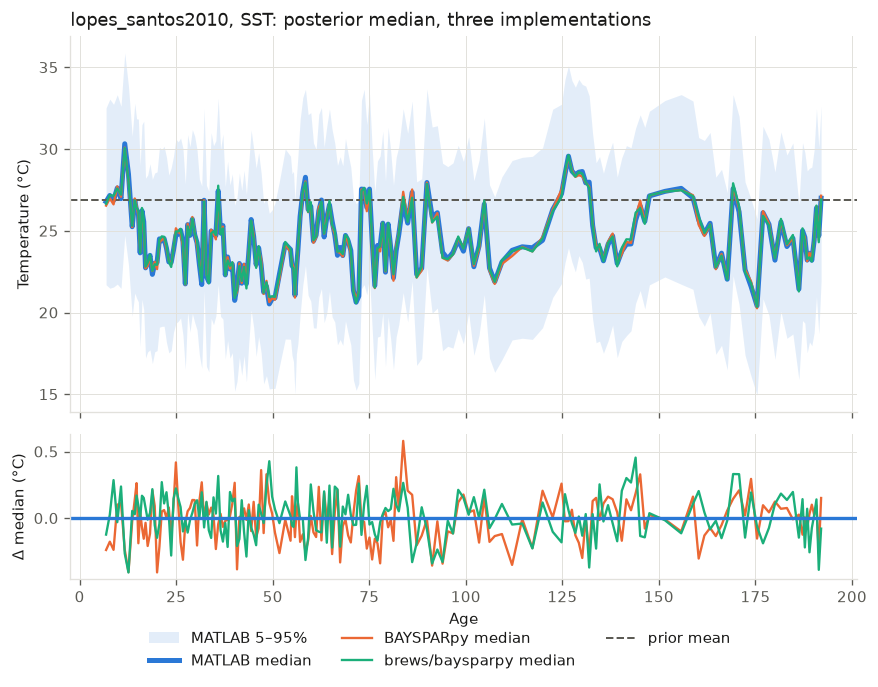

In [4]:
mo = sio.loadmat(str(ROOT / "ModelOutput" / "tex_testdata.mat"))
age = np.ravel(mo["lopes_santos2010"][0, 0]["age"]).astype(float)
order = np.argsort(age)

fig, (ax, axd) = plt.subplots(2, 1, figsize=(7.4, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [2.6, 1]})

ax.fill_between(age[order], matlab_preds[order, 0], matlab_preds[order, 2],
                color=COLORS["MATLAB"], alpha=0.13, linewidth=0,
                label="MATLAB 5–95%")
series = [("MATLAB", matlab_preds), ("BAYSPARpy", out_ours.preds)]
if HAVE_BREWS:
    series.append(("brews/baysparpy", brews_preds))
# the reference goes on thick and underneath, so the ports read as tracking it
for name, p in series:
    ax.plot(age[order], p[order, 1], lw=3 if name == "MATLAB" else 1.4,
            color=COLORS[name], label=f"{name} median", zorder=2 if name == "MATLAB" else 3)
ax.axhline(out_ours.prior_mean, color=MUTED, ls="--", lw=1.2, label="prior mean")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"lopes_santos2010, {runname}: posterior median, three implementations", loc="left")

# the lower panel reuses the same colours, so one figure-level legend serves both
for name, p in series[1:]:
    axd.plot(age[order], p[order, 1] - matlab_preds[order, 1], lw=1.4, color=COLORS[name])
axd.axhline(0, color=COLORS["MATLAB"], lw=2)
axd.set_ylabel("Δ median (°C)"); axd.set_xlabel("Age")
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
plt.show()

### Where the difference comes from

Three things separate the two Python ports from the reference, and they are separable. Holding two
fixed at a time shows the size of each:

1. **Which draws are used.** MATLAB thins with `round(linspace(1, 20000, n))` — draws 1, 21, 41 …,
   spread across the whole chain. `brews/baysparpy` ships only draws 10,001–20,000 of the same
   chain and takes the **first** `nens` of those: one contiguous block starting at draw 10,001.
2. **The percentile convention.** MATLAB's `prctile` uses Hazen plotting positions `(i−0.5)/n`;
   `brews/baysparpy` asks NumPy for `interpolation='nearest'`; NumPy's own default is a third thing.
3. **Monte-Carlo noise**, which is irreducible — the draws are random and the streams differ.

In [5]:
draws = ours.get_draws(runname)
cell = draws.cell_index(lon, lat)
spread = ours.matlab_thinning(draws.n_draws, N_DRAWS)     # MATLAB's choice
# brews ships draws 10,001-20,000 only (bit-identical to params_standard[:, 10000:]) and
# takes the first nens of them, so its draws are one block starting at draw 10,001
block = np.arange(10000, 10000 + N_DRAWS)                 # brews' choice

def preds_for(index, method, seed=SEED):
    rng = np.random.default_rng(seed)
    pm, ps = ours.solve_posterior(tex, draws.alpha[cell, index], draws.beta[cell, index],
                                  draws.tau2[index], out_ours.prior_mean, prior_std)
    ens = pm + rng.standard_normal(pm.shape) * ps
    return np.percentile(ens, [5, 50, 95], axis=1, method=method).T

base = preds_for(spread, "hazen")                 # what MATLAB does
print("effect of each choice on the median, degrees C (same seed, so no MC noise between rows):")
print(f"  draws: brews' block instead of spread   {np.abs(preds_for(block, 'hazen')[:,1] - base[:,1]).mean():.4f} mean, "
      f"{np.abs(preds_for(block, 'hazen')[:,1] - base[:,1]).max():.4f} max")
print(f"  percentile: 'nearest' instead of hazen   {np.abs(preds_for(spread, 'nearest')[:,1] - base[:,1]).mean():.4f} mean, "
      f"{np.abs(preds_for(spread, 'nearest')[:,1] - base[:,1]).max():.4f} max")
print(f"  both together                            {np.abs(preds_for(block, 'nearest')[:,1] - base[:,1]).mean():.4f} mean, "
      f"{np.abs(preds_for(block, 'nearest')[:,1] - base[:,1]).max():.4f} max")
mc = np.abs(preds_for(spread, "hazen", seed=1)[:,1] - base[:,1])
print(f"  Monte-Carlo noise alone (reseed)         {mc.mean():.4f} mean, {mc.max():.4f} max")
print()
print("the draws themselves differ:")
print(f"  mean alpha over MATLAB's spread draws {draws.alpha[cell, spread].mean():.6f}")
print(f"  mean alpha over brews' block          {draws.alpha[cell, block].mean():.6f}  (draws 10,001-{10000 + N_DRAWS:,})")

effect of each choice on the median, degrees C (same seed, so no MC noise between rows):
  draws: brews' block instead of spread   0.0770 mean, 0.2900 max
  percentile: 'nearest' instead of hazen   0.0041 mean, 0.0241 max
  both together                            0.0776 mean, 0.2902 max
  Monte-Carlo noise alone (reseed)         0.1455 mean, 0.4979 max

the draws themselves differ:
  mean alpha over MATLAB's spread draws 0.294660
  mean alpha over brews' block          0.291926  (draws 10,001-11,000)


## 2. Analogue mode — `Demo_AnalogPrediction.m`

Wilson Lake, PETM. `search_tol = 2 × std(TEX₈₆)`, `prior_mean = 30`, `prior_std = 20`. The analogue
**selection** is deterministic, so all three must agree on the set of grid cells exactly — that is
the sharpest check in this notebook.

In [6]:
ainp, aref = ref["analog_input"], ref["analog"]
wl_tex = np.atleast_1d(ainp.tex86)
search_tol, prior_mean_a, prior_std_a = (float(ainp.search_tol), float(ainp.prior_mean),
                                         float(ainp.prior_std))
matlab_an = np.atleast_2d(aref.Preds)
matlab_locs = np.atleast_2d(aref.AnLocs)

an_ours = ours.bayspar_tex_analog(wl_tex, prior_mean_a, prior_std_a, search_tol, str(ainp.runname),
                                  n_draws=N_DRAWS, mode="matlab", seed=SEED)
rows_a = [summarise("MATLAB", matlab_an), summarise("BAYSPARpy", an_ours.preds, matlab_an)]

locs_match = {"BAYSPARpy": np.array_equal(an_ours.analog_locs, matlab_locs)}
if HAVE_BREWS:
    an_brews = brews.predict_seatemp_analog(wl_tex, prior_std=prior_std_a,
                                            temptype=str(ainp.runname).lower(),
                                            search_tol=search_tol, prior_mean=prior_mean_a,
                                            nens=N_DRAWS, progressbar=False)
    try:
        brews_an = an_brews.percentile()
    except TypeError:
        brews_an = np.percentile(an_brews.ensemble, [5, 50, 95], axis=(1, 2), method="nearest").T
    rows_a.append(summarise("brews/baysparpy", brews_an, matlab_an))
    # his analog_gridpoints are (lat, lon) pairs; MATLAB's AnLocs are (lon, lat)
    bl = np.atleast_2d(np.asarray(an_brews.analog_gridpoints, dtype=float))
    locs_match["brews/baysparpy"] = sorted(map(tuple, bl[:, ::-1])) == sorted(map(tuple, matlab_locs))

print(f"{wl_tex.size} TEX86 values, mean {wl_tex.mean():.4f}, search_tol {search_tol:.4f}")
print(f"analogue cells: MATLAB {len(matlab_locs)} | BAYSPARpy {len(an_ours.analog_locs)}" +
      (f" | brews {len(bl)}" if HAVE_BREWS else ""))
for k, v in locs_match.items():
    print(f"  same cell set as MATLAB, exactly: {k} -> {v}")
print()
show(rows_a)

52 TEX86 values, mean 0.7742, search_tol 0.1754
analogue cells: MATLAB 24 | BAYSPARpy 24 | brews 24
  same cell set as MATLAB, exactly: BAYSPARpy -> True
  same cell set as MATLAB, exactly: brews/baysparpy -> True

implementation   p5 (median over points)  p50      p95    
---------------  -----------------------  -------  -------
MATLAB           22.7216                  29.7713  37.8623
BAYSPARpy        22.7557                  29.7589  37.8834
brews/baysparpy  22.7832                  29.7473  37.8293


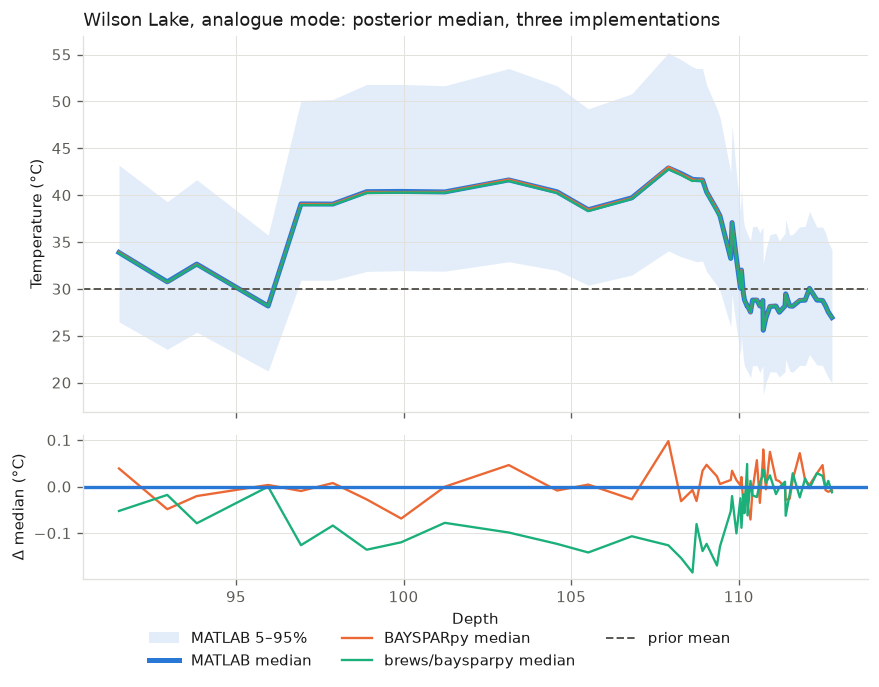

In [7]:
depth = np.ravel(sio.loadmat(str(ROOT / "ModelOutput" / "wilsonlake.mat"))["wilsonlake"][0, 0]["depth"]).astype(float)
o = np.argsort(depth)

fig, (ax, axd) = plt.subplots(2, 1, figsize=(7.4, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [2.6, 1]})
ax.fill_between(depth[o], matlab_an[o, 0], matlab_an[o, 2], color=COLORS["MATLAB"],
                alpha=0.13, linewidth=0, label="MATLAB 5–95%")
series_a = [("MATLAB", matlab_an), ("BAYSPARpy", an_ours.preds)]
if HAVE_BREWS:
    series_a.append(("brews/baysparpy", brews_an))
for name, p in series_a:
    ax.plot(depth[o], p[o, 1], lw=3 if name == "MATLAB" else 1.4,
            color=COLORS[name], label=f"{name} median", zorder=2 if name == "MATLAB" else 3)
ax.axhline(prior_mean_a, color=MUTED, ls="--", lw=1.2, label="prior mean")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Wilson Lake, analogue mode: posterior median, three implementations", loc="left")

for name, p in series_a[1:]:
    axd.plot(depth[o], p[o, 1] - matlab_an[o, 1], lw=1.4, color=COLORS[name])
axd.axhline(0, color=COLORS["MATLAB"], lw=2)
axd.set_ylabel("Δ median (°C)"); axd.set_xlabel("Depth")
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
plt.show()

## 3. Cost

The prediction is a conjugate normal update with a **diagonal** prior covariance, so the posterior
is diagonal too and the whole thing is elementwise arithmetic. `brews/baysparpy` builds an N × N
matrix and takes a `solve` plus a Cholesky **once per posterior draw** — and once per draw *per
analogue location* in analogue mode — which is where both the wall-clock and the all-cores
behaviour come from. The threads are not the problem; the O(N³) work per draw is.

In [8]:
def timed(fn, *a, **k):
    t0, c0 = time.perf_counter(), time.process_time()
    fn(*a, **k)
    return time.perf_counter() - t0, time.process_time() - c0

t_ours, c_ours = timed(ours.bayspar_tex, tex, lon, lat, prior_std, runname,
                       n_draws=N_DRAWS, seed=SEED)
print(f"standard mode, N={tex.size}, {N_DRAWS} draws")
print(f"  BAYSPARpy        {t_ours:7.3f} s wall  {c_ours/max(t_ours,1e-9):4.1f} cores busy")
if HAVE_BREWS:
    t_b, c_b = timed(brews.predict_seatemp, tex, lat=lat, lon=lon, prior_std=prior_std,
                     temptype=runname.lower(), nens=N_DRAWS)
    print(f"  brews/baysparpy  {t_b:7.3f} s wall  {c_b/max(t_b,1e-9):4.1f} cores busy   "
          f"-> {t_b/t_ours:.0f}x slower")
    print(f"\n  at his default nens=5000 that is about {t_b*5:.0f} s for this record;")
    print(f"  in analogue mode it is multiplied again by the number of analogue cells "
          f"({len(matlab_locs)} here).")

standard mode, N=193, 1000 draws
  BAYSPARpy          0.008 s wall   1.0 cores busy


  brews/baysparpy    0.763 s wall   7.9 cores busy   -> 94x slower

  at his default nens=5000 that is about 4 s for this record;
  in analogue mode it is multiplied again by the number of analogue cells (24 here).


## Summary

- **The analogue cell selection agrees exactly**, which is the part with no sampling noise in it.
- **Prior means agree exactly** across all three.
- **The median differences are smaller than the sampling noise.** Using `brews/baysparpy`'s block
  of 1000 draws (10,001–11,000) instead of MATLAB's spread moves the median by 0.08 °C on average; the percentile convention moves
  it by 0.004 °C; reseeding the *same* implementation moves it by 0.15 °C. No implementation is
  systematically warm or cold in standard mode.
- **In analogue mode the draw choice does show as a small offset**, because every analogue location
  reuses the same contiguous block of 1000 draws rather than averaging the difference away: `brews/baysparpy` sits
  0.04–0.05 °C below the reference on average across the Wilson Lake record (checked over four
  seeds), where this port averages zero. Still far inside the 5–95% band, but systematic rather than random.
- `brews/baysparpy` is **roughly 100× slower at N = 193 (94–127× across runs) and uses every core**, for arithmetic that is elementwise.
- On NumPy ≥ 2.0 his `Prediction.percentile()` raises, because `np.percentile(interpolation=...)`
  was removed in NumPy 2.0; the ensemble itself is fine and the cell above recomputes from it.

For the line-by-line account of how this port differs from the MATLAB, see
`docs/BAYSPARpy/PORTING.md` — 45 entries, 10 of which change behaviour.